In [43]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()

True

In [44]:
class BatsmanState(TypedDict):
    
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percentage: float

In [45]:
def calculate_sr(state: BatsmanState):
    sr=(state['runs']/state['balls'])*100
    return {'sr': sr}

In [46]:
def calculate_bpb(state: BatsmanState):
    bpb=state['balls']/(state['fours']+state['sixes'])
    return {'bpb': bpb}

In [47]:
def calculate_boundary_percentage(state: BatsmanState):
    boundary_percentage=((state['fours']+state['sixes'])/state['balls'])*100
    return {'boundary_percentage': boundary_percentage}

In [48]:
def summary(state=BatsmanState):
    summary=f"""
    Runs: {state['runs']}\nBalls: {state['balls']}\nFours: {state['fours']}\nSixes: {state['sixes']}\nSR: {state['sr']:.2f}\nBPB: {state['bpb']:.2f}\nBoundary Percentage: {state['boundary_percentage']:.2f}%"""
    return {'summary': summary}

In [49]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr',calculate_sr)
graph.add_node('summary',summary)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('calculate_boundary_percentage',calculate_boundary_percentage)

In [50]:
graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_boundary_percentage')

graph.add_edge('calculate_bpb','summary')
graph.add_edge('calculate_sr','summary')
graph.add_edge('calculate_boundary_percentage','summary') 

graph.add_edge('summary',END)

workflow = graph.compile()


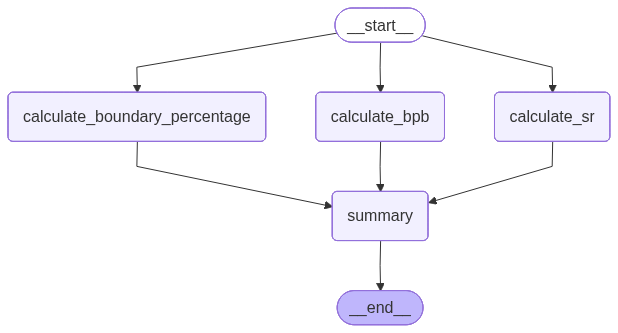

In [51]:
workflow

In [52]:
initial_state = BatsmanState(runs=120, balls=80, fours=15, sixes=5)
workflow.invoke(initial_state)

{'runs': 120,
 'balls': 80,
 'fours': 15,
 'sixes': 5,
 'sr': 150.0,
 'bpb': 4.0,
 'boundary_percentage': 25.0}